# GTSRB Traffic Sign Classifier

The main event: classifying German traffic signs (43 classes, real-world photos).
Two models are compared on the same data to show why CNNs exist:

| model | test accuracy |
|---|---|
| MLP (flatten + linear, same as the MNIST net) | 72.39% |
| CNN (2 conv layers) + data augmentation | **91.15%** |

Key lessons learned along the way:
- Flattening destroys spatial structure; conv layers preserve and exploit it
- GTSRB training images come from video (~30 near-identical frames per physical sign), so the model overfits by memorizing signs - augmentation fights this
- Training loss going down does not mean test accuracy goes up (overfitting)
- Evaluate every epoch and keep the best weights, instead of hoping the last epoch is the best

In [140]:
# Imports: torchvision for the GTSRB dataset, v2 transforms for preprocessing/augmentation,
# DataLoader for batching, torch/nn for the models, copy for snapshotting the best weights
import os
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import numpy as np
from torchvision.transforms import v2
import torch.nn.functional as F
import copy

## 1. Transforms and data

GTSRB images come in all sizes (15x15 up to 250x250), so everything is resized to 32x32.
Training gets **augmentation** (random rotation + brightness/contrast jitter) so the model
can't just memorize the ~30 near-identical video frames of each physical sign.
The test pipeline must stay deterministic - randomness belongs to training only.

Note: no horizontal flips! A mirrored 'turn left' sign IS a 'turn right' sign -
augmentation must never change what the correct label would be.

In [141]:
# Training transform: resize -> augment -> tensor -> normalize
transform_train = v2.Compose([
    v2.Resize((32, 32)),
    v2.RandomRotation(10),                          # rotate up to +/-10 degrees (a tilted sign is still the same sign)
    v2.ColorJitter(brightness=0.3, contrast=0.3),   # simulate different lighting conditions
    v2.ToImage(),                                   # PIL image -> tensor
    v2.ToDtype(torch.float32, scale = True),        # ints 0-255 -> floats 0-1
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # center around 0, one mean/std per RGB channel
])

# Test transform: same preprocessing but NO augmentation - the test set is a fixed exam
transform_test = v2.Compose([
    v2.Resize((32, 32)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [142]:
# Download GTSRB (auto-downloads into ../data on first run)
# Each dataset gets its matching transform: augmented for train, deterministic for test
train_data = datasets.GTSRB(root='../data', split='train', download=True, transform=transform_train)
test_data = datasets.GTSRB(root='../data', split='test', download=True, transform=transform_test)

print(f'Training samples: {len(train_data)}')
print(f'Test samples: {len(test_data)}')

Training samples: 26640
Test samples: 12630


[ 150 1500 1500  960 1320 1260  300  960  960  990 1350  900 1410 1440
  540  420  300  750  810  150  240  240  270  360  180 1020  420  180
  360  180  300  540  180  480  300  810  270  150 1380  210  240  180
  180]


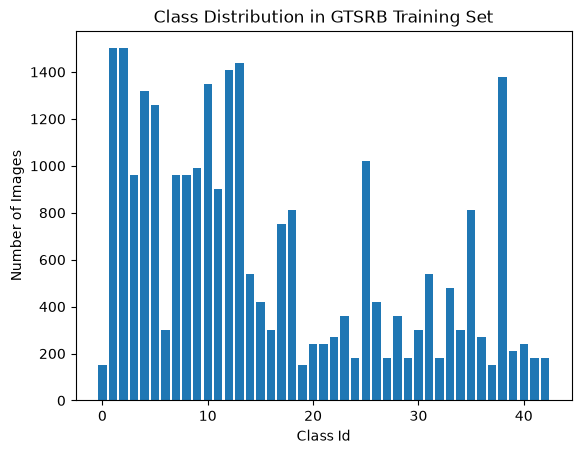

In [143]:
# Class distribution: heavily imbalanced - from 150 images (rare signs)
# up to 1500 (common speed limits). Rare classes will likely be the weak spots.
labels = [label for _, label in train_data._samples]
counts = np.bincount(labels)
print(counts)

plt.bar(range(len(counts)), counts)
plt.xlabel('Class Id')
plt.ylabel('Number of Images')
plt.title('Class Distribution in GTSRB Training Set')
plt.show()


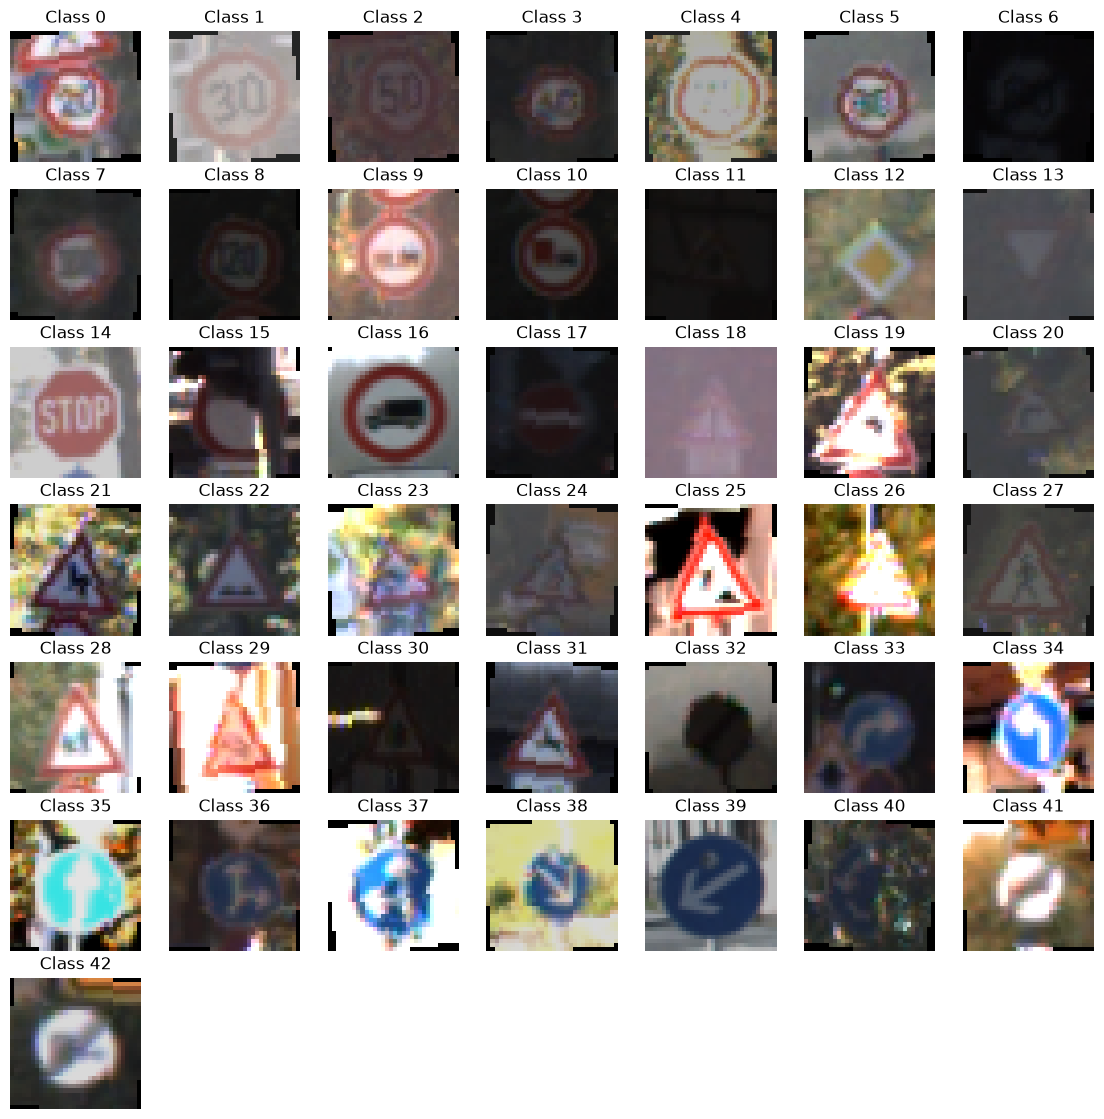

In [144]:
# One sample per class (as the model sees them: resized + augmented).
# Two display fixes are needed because the data is now tensors, not PIL images:
#   - un-normalize (x * std + mean) because imshow wants pixel values in 0-1
#   - permute (C,H,W) -> (H,W,C) because imshow wants channels last
first_idx = [labels.index(i) for i in range(len(counts))]
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(7, 7, figsize=(14, 14))
for i in range(len(counts)):
    image, label = train_data[first_idx[i]]
    image = image * std + mean
    ax = axes[i // 7, i % 7]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f'Class {label}')
    ax.axis('off')

for i in range(len(counts), 49):
    ax = axes[i // 7, i % 7]
    ax.axis('off')


In [145]:
# DataLoaders chunk the datasets into batches of 64 images
# shuffle=True for training (GTSRB is stored grouped by class - order bias otherwise)
# shuffle=False for test (accuracy is just a count; order can't change it)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# One batch = 64 images of shape [3, 32, 32] and 64 labels
image, label = next(iter(train_loader))
print(image.shape)
print(label.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


## 2. Baseline: fully-connected net (MLP)

Same architecture that scored 97% on MNIST. It flattens the image into one long
vector, so all spatial structure (which pixels are neighbors) is thrown away.
Trained for 3 epochs it reaches **72.39%** on GTSRB - the baseline the CNN has to beat.

In [146]:
# A simple fully-connected network:
#   flatten: 3x32x32 image -> 3072 numbers (spatial layout destroyed)
#   layer1:  3072 -> 128 neurons
#   relu:    negatives become 0 (lets the network learn non-linear patterns)
#   layer2:  128 -> 43 output scores, one per traffic sign class
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(3072, 128)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 43)

    def forward(self, x):
        # Defines the path data takes through the network
        x = self.flatten(x)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


# Sanity check: push one batch through the untrained model, expect [64, 43]
model = SimpleNet()
image, label = next(iter(train_loader))
output = model(image)
print(output.shape)  # Should be [batch_size, 43]


torch.Size([64, 43])


In [147]:
# CrossEntropyLoss: standard classification loss, punishes confident wrong answers
# Adam: adjusts weights to reduce the loss; lr controls the step size
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [148]:
# Train the MLP baseline: 3 epochs (~417 batches each)
for epoch in range(3): 
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()  # wipe gradients from the previous batch
        outputs = model(images)  # forward pass: predict
        loss = loss_fn(outputs, labels)  # measure how wrong we were
        loss.backward()  # work out which way to adjust each weight
        optimizer.step()  # apply the adjustments
        total_loss += loss.item()  # track loss for the epoch average
    print(f"Epoch [{epoch+1}/3], Avg Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/3], Avg Loss: 1.6580
Epoch [2/3], Avg Loss: 0.7711
Epoch [3/3], Avg Loss: 0.5810


In [149]:
# Evaluate the MLP baseline on the 12,630 test images it has never seen
correct = 0
total = 0
with torch.no_grad():                        # no training here, so skip gradient tracking
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) # index of the highest score = predicted sign
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 72.39%


## 3. The CNN

Only two new layer types compared to the MLP:

- **Conv2d** slides small 3x3 filters across the image. Each filter learns one local
  pattern (an edge, a red arc...) and the *same* filter is reused everywhere, so a
  pattern is found no matter where it appears. `padding=1` keeps height/width unchanged.
- **MaxPool2d(2)** cuts the image into 2x2 tiles and keeps the strongest value from each,
  halving the size. Keeps "did I find it", discards "which exact pixel" - which buys
  tolerance to small shifts.

Shape trace (conv changes channels only, pool halves height/width only):
```
[3, 32, 32] -> conv1 -> [16, 32, 32] -> pool -> [16, 16, 16]
            -> conv2 -> [32, 16, 16] -> pool -> [32, 8, 8]
            -> flatten -> 32*8*8 = 2048
```

In [150]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 3 RGB channels in, 16 pattern detectors out
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # in must match conv1's out
        self.pool = nn.MaxPool2d(2)   # no learnable weights, so one module reused twice
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(2048, 128)  # 32 channels * 8 * 8 after two pools
        self.layer2 = nn.Linear(128, 43)    # one score per traffic sign class

    def forward(self, x):
        # Defines the path data takes through the network
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)      # 32x32 -> 16x16
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)      # 16x16 -> 8x8
        x = self.flatten(x)   # [32, 8, 8] -> 2048
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


# Sanity check: expect [64, 43] again
model = ConvNet()
image, label = next(iter(train_loader))
output = model(image)
print(output.shape)  # Should be [batch_size, 43]


torch.Size([64, 43])


## 4. Train and evaluate the CNN

Augmented data is harder to memorize, so the CNN gets 8 epochs instead of 3.
Note in the results below: training loss keeps falling every epoch, but test accuracy
plateaus around 88-89% - the two are not the same thing. The best epoch's weights
are snapshotted and restored at the end.

In [151]:
# Fresh loss + optimizer bound to the CNN's weights
# (an optimizer remembers which model it was built for - reusing the MLP's would silently train nothing)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [152]:
# Train the CNN, evaluating after EVERY epoch (one endpoint number hides the curve -
# an earlier run peaked at epoch 7 with 89.22% but ended lower at epoch 8).
# Whenever test accuracy hits a new high, snapshot the weights so the best model
# is never lost, and restore that snapshot at the end.
best_acc = 0
best_state = None

for epoch in range(8):
    # ---- training ----
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()  # wipe gradients from the previous batch
        outputs = model(images)  # forward pass: predict
        loss = loss_fn(outputs, labels)  # measure how wrong we were
        loss.backward()  # work out which way to adjust each weight
        optimizer.step()  # apply the adjustments
        total_loss += loss.item()  # track loss for the epoch average

    # ---- evaluation after every epoch ----
    correct = 0
    total = 0
    with torch.no_grad():  # no training here, so skip gradient tracking
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)  # index of the highest score = predicted sign
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    if acc > best_acc:                                   # new best? snapshot the weights
        best_acc = acc
        best_state = copy.deepcopy(model.state_dict())   # deepcopy: a live reference would keep changing as training continues

    print(f"Epoch [{epoch+1}/8], Avg Loss: {total_loss/len(train_loader):.4f}, Test Acc: {acc:.2f}%")

print(f"\nBest Test Accuracy: {best_acc:.2f}%")

Epoch [1/8], Avg Loss: 1.5363, Test Acc: 76.28%
Epoch [2/8], Avg Loss: 0.3220, Test Acc: 85.56%
Epoch [3/8], Avg Loss: 0.1735, Test Acc: 87.29%
Epoch [4/8], Avg Loss: 0.1191, Test Acc: 88.50%
Epoch [5/8], Avg Loss: 0.0825, Test Acc: 89.62%
Epoch [6/8], Avg Loss: 0.0671, Test Acc: 90.65%
Epoch [7/8], Avg Loss: 0.0615, Test Acc: 91.15%
Epoch [8/8], Avg Loss: 0.0541, Test Acc: 90.03%

Best Test Accuracy: 91.15%


In [153]:
# Restore the best snapshot (the model currently holds the LAST epoch's weights,
# which are not necessarily the best) and confirm its accuracy
model.load_state_dict(best_state)

correct = 0
total = 0
with torch.no_grad():                        # no training here, so skip gradient tracking
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) # index of the highest score = predicted sign
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 91.15%


## 5. Export the model

Save the best weights to disk so other scripts can use the classifier without retraining.
Only the weights (state_dict) are saved, not the architecture - so any consumer needs
the ConvNet class definition too, then loads with:

```python
model = ConvNet()
model.load_state_dict(torch.load('../models/gtsrb_cnn.pt'))
model.eval()
```

(*.pt files are gitignored - the weights are reproducible by re-running this notebook.)

In [154]:
os.makedirs('../models', exist_ok=True)   # create the folder if it doesn't exist yet

# Save the BEST weights (not the last epoch's) to disk
torch.save(best_state, '../models/gtsrb_cnn.pt')
print(f"Saved best model ({best_acc:.2f}%) to ../models/gtsrb_cnn.pt")

Saved best model (91.15%) to ../models/gtsrb_cnn.pt
